In [ ]:
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings('ignore')

### 1. Data Loading & Preparation (Initial Inspection)

In [ ]:
df = pd.read_csv('AAPL.csv')
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,1980-12-12,0.128348,0.128906,0.128348,0.128348,0.100178,469033600
1,1980-12-15,0.122210,0.122210,0.121652,0.121652,0.094952,175884800
2,1980-12-16,0.113281,0.113281,0.112723,0.112723,0.087983,105728000
3,1980-12-17,0.115513,0.116071,0.115513,0.115513,0.090160,86441600
4,1980-12-18,0.118862,0.119420,0.118862,0.118862,0.092774,73449600


Check datatype.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10468 entries, 0 to 10467
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       10468 non-null  object 
 1   Open       10468 non-null  float64
 2   High       10468 non-null  float64
 3   Low        10468 non-null  float64
 4   Close      10468 non-null  float64
 5   Adj Close  10468 non-null  float64
 6   Volume     10468 non-null  int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 572.6+ KB


Check missing values.

In [ ]:
df.isnull().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0
Adj Close,0
Volume,0


 `Date` column is currently of type 'object', so we'll need to convert it to a datetime object for proper time series analysis.

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10468 entries, 0 to 10467
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       10468 non-null  datetime64[ns]
 1   Open       10468 non-null  float64       
 2   High       10468 non-null  float64       
 3   Low        10468 non-null  float64       
 4   Close      10468 non-null  float64       
 5   Adj Close  10468 non-null  float64       
 6   Volume     10468 non-null  int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 572.6 KB


Set `Date` as the index of the DataFrame. This will help us with time-series operations, allwoing for easier & more intuitive operations when working with time-based data.

In [ ]:
df.set_index('Date', inplace=True)
display(df.head())

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
1980-12-12,0.128348,0.128906,0.128348,0.128348,0.100178,469033600
1980-12-15,0.122210,0.122210,0.121652,0.121652,0.094952,175884800
1980-12-16,0.113281,0.113281,0.112723,0.112723,0.087983,105728000
1980-12-17,0.115513,0.116071,0.115513,0.115513,0.090160,86441600
1980-12-18,0.118862,0.119420,0.118862,0.118862,0.092774,73449600


### 2. Exploratory Data Analysis (EDA)

Since our data is now prepared, lets visualize the stock prices to observe trends & patterns over time, helping us gain insights into the data before building our GRU model.

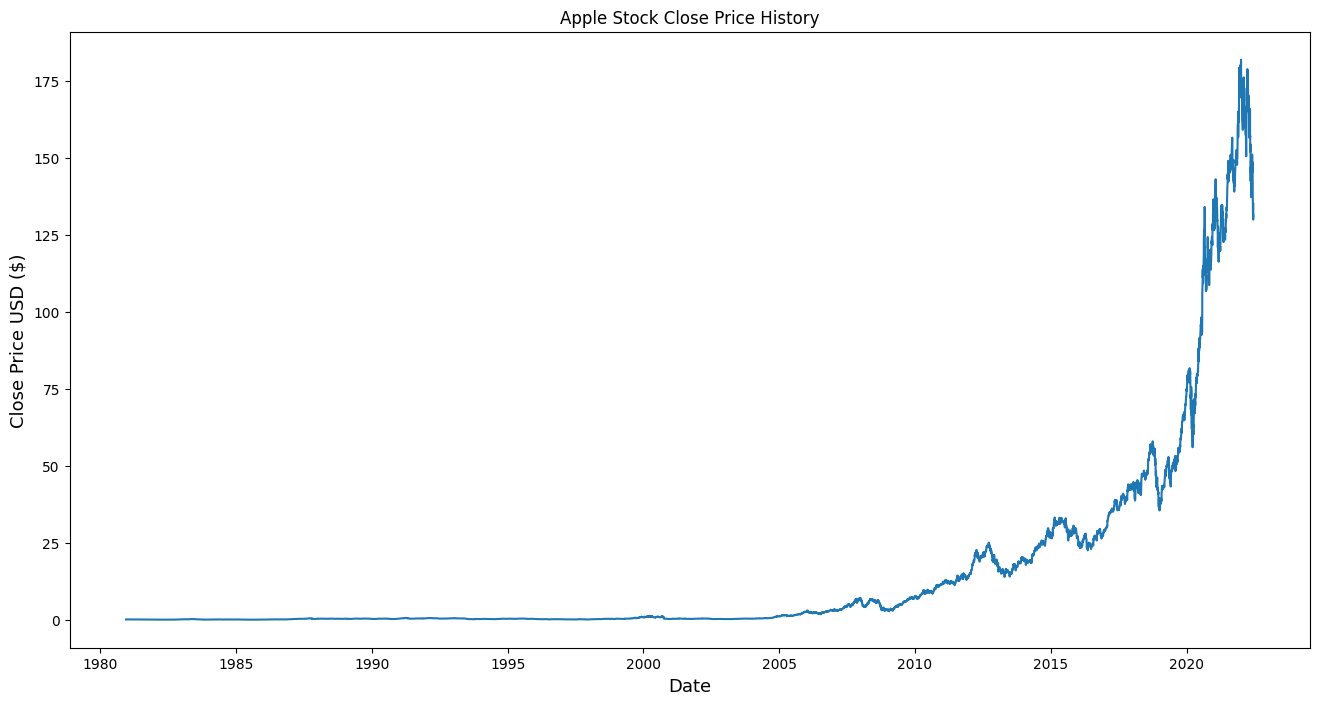

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot the 'Close' price over time
plt.figure(figsize=(16, 8))   # Set up the matplotlib figure
plt.title('Apple Stock Close Price History')
plt.plot(df['Close'])
plt.xlabel('Date', fontsize=13)
plt.ylabel('Close Price USD ($)', fontsize=13)
plt.show()

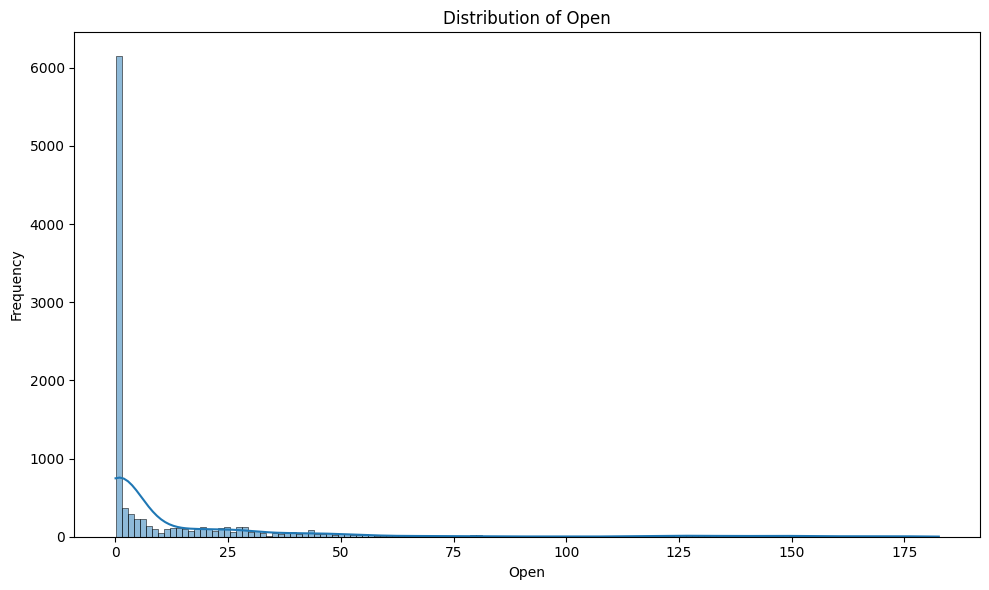

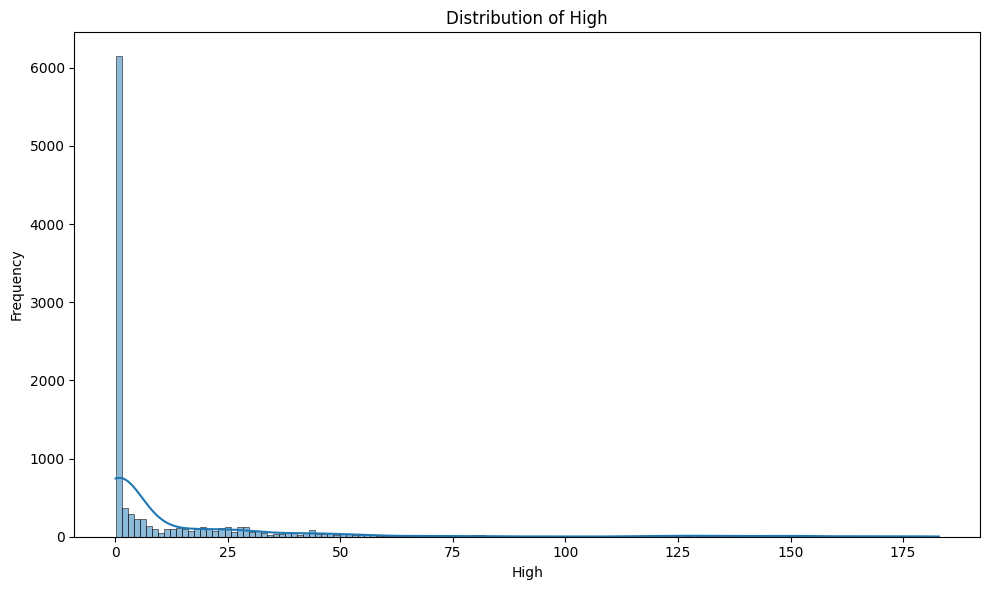

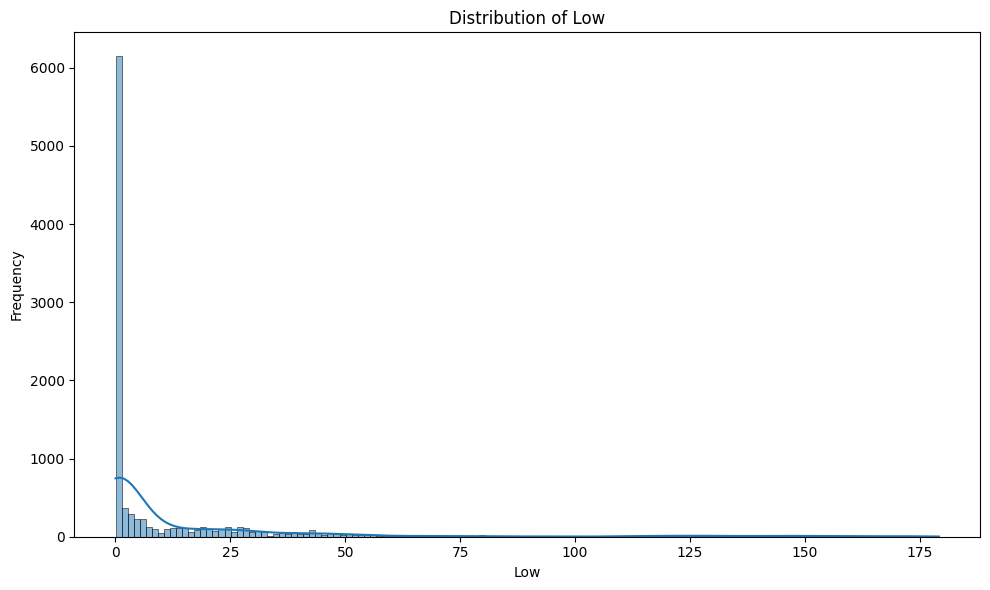

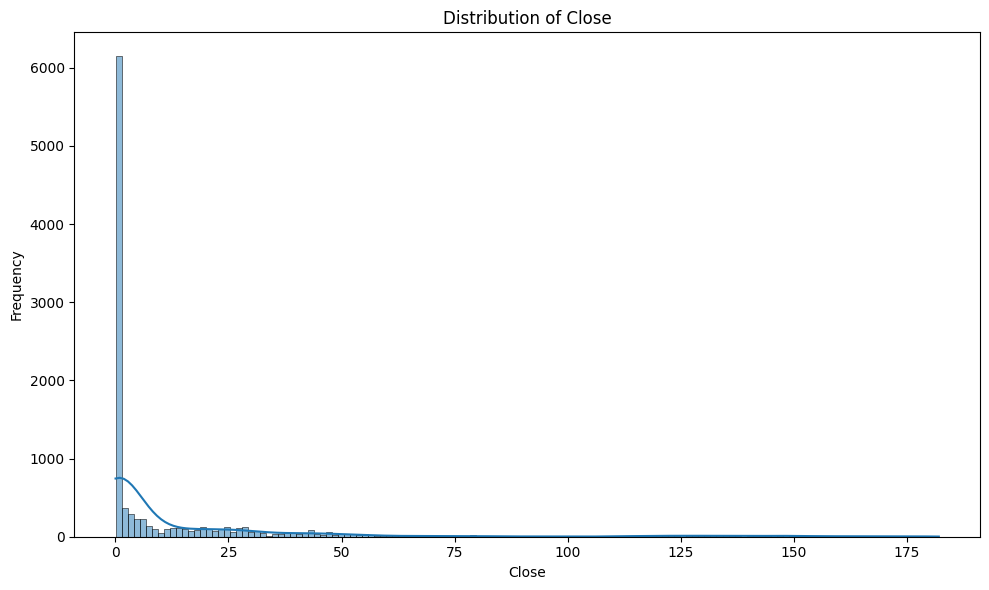

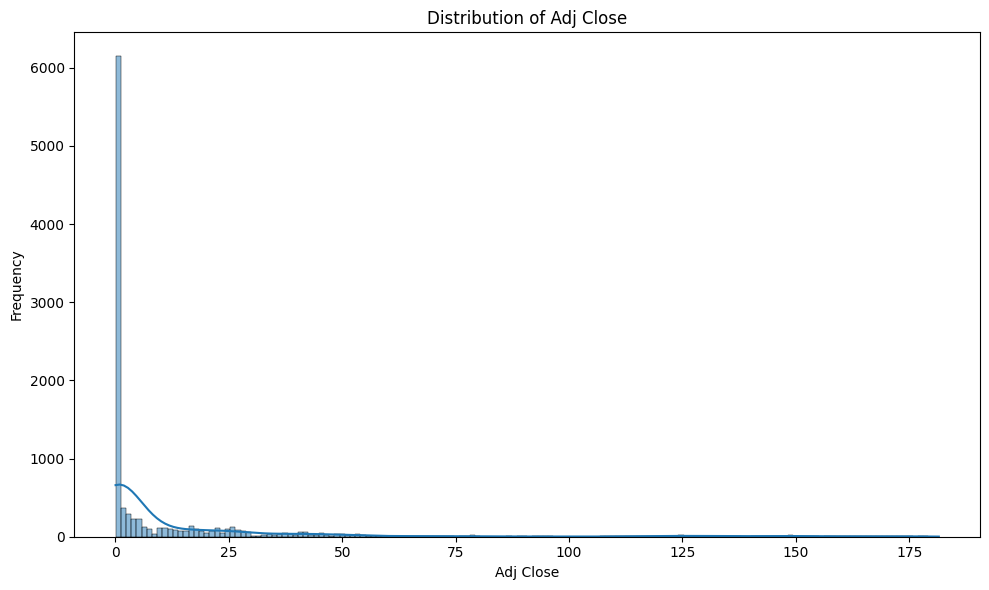

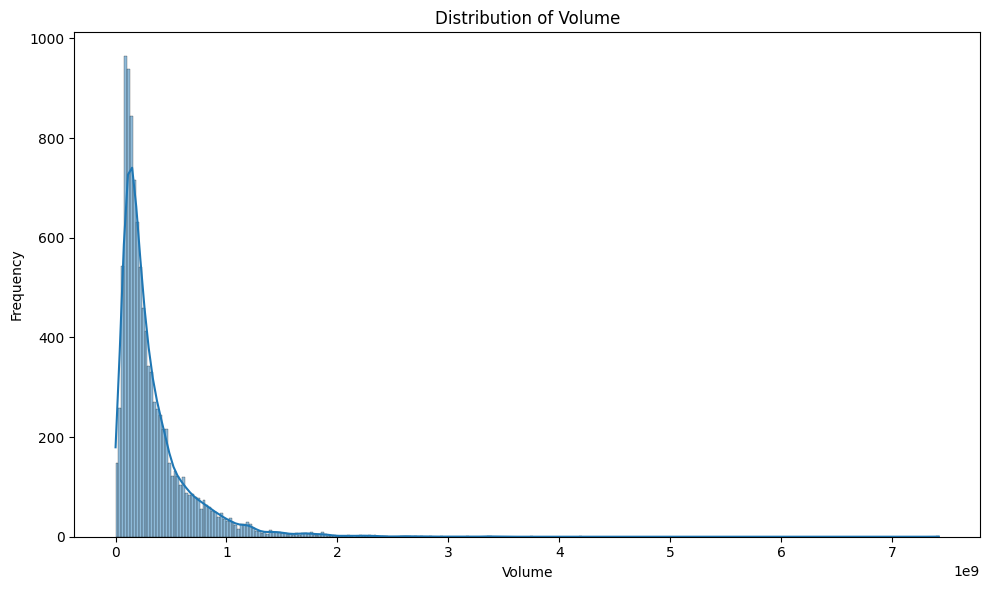

In [ ]:
# Create a list of columns to plot
columns_to_plot = ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']

# Loop through the columns and create a separate histogram for each
for column in columns_to_plot:
    plt.figure(figsize=(10, 6)) # Create a new figure for each plot
    sns.histplot(df[column], kde=True)
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

### 3. Feature Selection

Considering the nature of stock price prediction & the capabiilities of a GRU model, we will be selecting the `Open`, `High`, `Low`, `Close`, & `Volume` columns.

In [ ]:
features = ['Open', 'High', 'Low', 'Close', 'Volume']
data = df[features]
data.head()

,Open,High,Low,Close,Volume
Date,,,,,
1980-12-12,0.128348,0.128906,0.128348,0.128348,469033600
1980-12-15,0.122210,0.122210,0.121652,0.121652,175884800
1980-12-16,0.113281,0.113281,0.112723,0.112723,105728000
1980-12-17,0.115513,0.116071,0.115513,0.115513,86441600
1980-12-18,0.118862,0.119420,0.118862,0.118862,73449600


### 4. Feature/Data Scaling

Deep Learning models, esp. GRUs, are very sensitive to the scale of the input data. Scaling helps normalize the range of independent variables, which can prevent features with larger values from dominating the learning process and helps the model converge faster and more efficiently.

We will scale these features using Min-Max scaling.

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

# Display the first 5 rows of the scaled data
print("First 5 rows of scaled data:")
pd.DataFrame(scaled_data, columns=data.columns, index=data.index).head()

First 5 rows of scaled data:


,Open,High,Low,Close,Volume
Date,,,,,
1980-12-12,0.000431,0.000433,0.000443,0.000435,0.063198
1980-12-15,0.000397,0.000397,0.000405,0.000399,0.023699
1980-12-16,0.000348,0.000348,0.000355,0.000350,0.014246
1980-12-17,0.000361,0.000363,0.000371,0.000365,0.011647
1980-12-18,0.000379,0.000381,0.000390,0.000383,0.009897


### 5. Data Splitting

Split the `scaled_data` into training and testing sets.

In [ ]:
# Define the split ratio (e.g., 80% for training)
training_data_len = int(np.ceil(len(scaled_data) * 0.8))

# Split the data
train_data = scaled_data[0:training_data_len, :]
test_data = scaled_data[training_data_len - 60:, :]

print(f"Shape of training data: {train_data.shape}")
print(f"Shape of testing data: {test_data.shape}")

Shape of training data: (8375, 5)
Shape of testing data: (2153, 5)


### 6. Create Sequences For Training & Testing Data

Create X and y sequences for training data.

In [ ]:
X_train, y_train = [], []
look_back = 60 # Number of previous time steps to consider for prediction

for i in range(look_back, len(train_data)):
    X_train.append(train_data[i-look_back:i, :])
    y_train.append(train_data[i, 3]) # 'Close' price is at index 3 in 'data' DataFrame

# Convert the lists to numpy arrays
X_train, y_train = np.array(X_train), np.array(y_train)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")

Shape of X_train: (8315, 60, 5)
Shape of y_train: (8315,)


Create X and y sequences for test data.

In [ ]:
X_test, y_test = [], []

for i in range(look_back, len(test_data)):
    X_test.append(test_data[i-look_back:i, :])
    y_test.append(test_data[i, 3]) # 'Close' price is at index 3 in 'data' DataFrame

# Convert the lists to numpy arrays
X_test, y_test = np.array(X_test), np.array(y_test)

print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_test: (2093, 60, 5)
Shape of y_test: (2093,)


### 7. Building & Training The GRU Model

Model Building.

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Build the GRU model (we wil stack 2 GRU layers)
model = Sequential()
model.add(GRU(units=50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.2))
model.add(GRU(units=50, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(units=1)) # Output layer for predicting one value (Close price)

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Define Early Stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss', # Monitor the validation loss
    patience=10,        # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True # Restore model weights from the epoch with the best value of the monitored quantity
)

# Display model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 60, 50)         │         8,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 50)             │        15,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,901 (93.36 KB)

 Trainable params: 23,901 (93.36 KB)

 Non-trainable params: 0 (0.00 B)

Model Training.

In [ ]:
# Train the model with Early Stopping
history_early_stop = model.fit(X_train, y_train,
                               epochs=100, # Set a higher number of epochs, EarlyStopping will stop it sooner
                               batch_size=32,
                               verbose=1,
                               validation_split=0.2,
                               callbacks=[early_stopping] # Add the EarlyStopping callback
                              )

Epoch 1/100
208/208 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 1.5366e-05 - val_loss: 1.5404e-05
Epoch 2/100
208/208 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 2.0092e-06 - val_loss: 9.6884e-06
Epoch 3/100
208/208 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 1.2955e-06 - val_loss: 1.4964e-05
Epoch 4/100
208/208 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1.0251e-06 - val_loss: 5.4156e-06
Epoch 5/100
208/208 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 7.1292e-07 - val_loss: 4.3715e-06
Epoch 6/100
208/208 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 6.8567e-07 - val_loss: 8.1879e-06
Epoch 7/100
208/208 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5.9531e-07 - val_loss: 4.0098e-06
Epoch 8/100
208/208 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 6.9500e-07 - val_loss: 1.6309e-05
Epoch 9/100
208/208 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 5.8959e-07 - val_loss: 4.2999e-06
Epoch 10/100
208/208 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 6.1811e-07 - val_loss: 9.3203e-06
Epoch 11/100
208/208 ━━━━━━━━━━━━━━━━━━━━ 2s

Plot training & vaidation loss over epochs to see how well the model learned during training and if there are any signs of overfitting or underfitting.

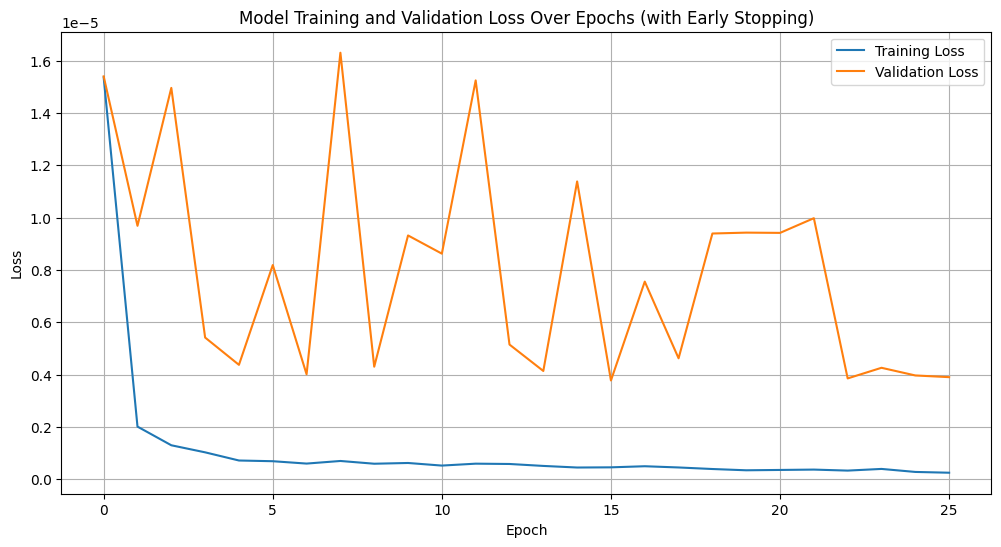

In [ ]:
# Plot training & validation loss over epochs with early stopping
plt.figure(figsize=(12, 6))
plt.plot(history_early_stop.history['loss'], label='Training Loss')
plt.plot(history_early_stop.history['val_loss'], label='Validation Loss')
plt.title('Model Training and Validation Loss Over Epochs (with Early Stopping)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

### 8. Model Evaluation On Test Data

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Make predictions on the test data
predictions = model.predict(X_test)

# Inverse transform the predictions to original scale
# The scaler was fitted on the entire 'data' (5 features).
# We need to create a dummy array for inverse transformation.
# The 'Close' price is at index 3 in the original 'data' DataFrame and scaled_data (0-indexed)
# So, we'll create an array with predictions in the 'Close' column position and zeros elsewhere.

# Create a dummy array with the same number of features as the original scaled_data
predictions_full_scale = np.zeros((predictions.shape[0], data.shape[1]))
predictions_full_scale[:, 3] = predictions[:, 0] # Place predictions in the 'Close' price column (index 3)

# Inverse transform only the 'Close' price predictions
predictions = scaler.inverse_transform(predictions_full_scale)[:, 3]

# Inverse transform y_test to original scale
y_test_full_scale = np.zeros((y_test.shape[0], data.shape[1]))
y_test_full_scale[:, 3] = y_test
y_test = scaler.inverse_transform(y_test_full_scale)[:, 3]

# Calculate evaluation metrics
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, predictions)

print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")

66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Mean Squared Error (MSE): 37.4646
Root Mean Squared Error (RMSE): 6.1208
Mean Absolute Error (MAE): 3.3399


MAE of 3.39 means that, on average, our model's predictions for the Apple stock's closing price is off by only 3.39

Plot the actual vs predicted values.

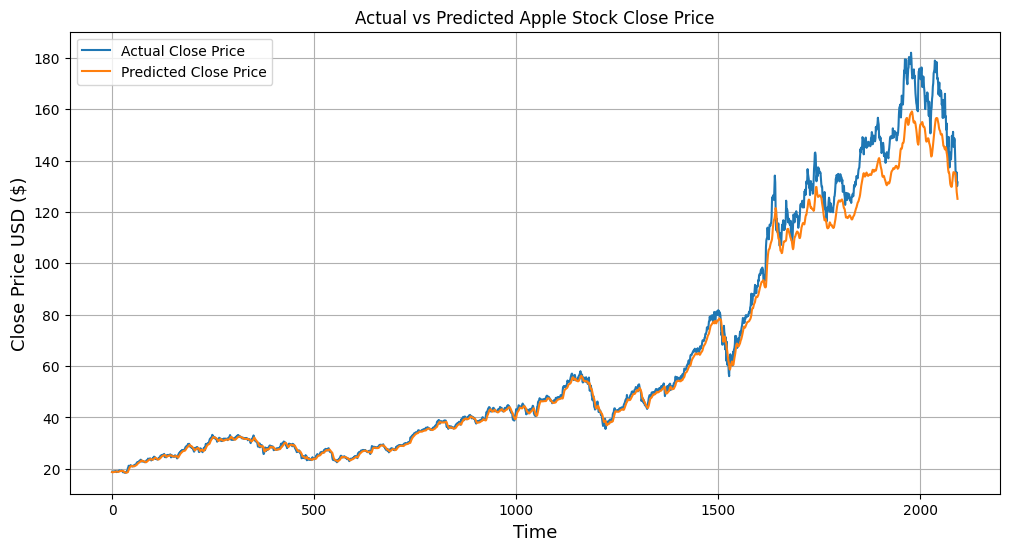

In [ ]:
# Plotting actual vs predicted values
plt.figure(figsize=(12, 6))
plt.plot(y_test, label='Actual Close Price')
plt.plot(predictions, label='Predicted Close Price')
plt.title('Actual vs Predicted Apple Stock Close Price')
plt.xlabel('Time', fontsize=13)
plt.ylabel('Close Price USD ($)', fontsize=13)
plt.legend()
plt.grid(True)
plt.show()

### 17. Retraining the Best Model on the Entire Dataset

To prepare the model for real-world future predictions, we train the best-performing model architecture (the one without technical indicators) on the entire `scaled_data`.

In [ ]:
# Re-create X and y sequences from the *entire* scaled_data (original 5 features)
# Ensure 'data' here refers to the 5-feature DataFrame, not the one with indicators
# Let's reconstruct the 5-feature data first to be safe
original_features = ['Open', 'High', 'Low', 'Close', 'Volume']
data_original = df[original_features].copy()

# Re-scale the original_features data
scaler_full_data = MinMaxScaler(feature_range=(0, 1))
scaled_data_full = scaler_full_data.fit_transform(data_original)

X_full, y_full = [], []
look_back = 60 # Same look_back period

for i in range(look_back, len(scaled_data_full)):
    X_full.append(scaled_data_full[i-look_back:i, :])
    y_full.append(scaled_data_full[i, original_features.index('Close')]) # 'Close' price is at index 3

# Convert to numpy arrays
X_full, y_full = np.array(X_full), np.array(y_full)

print(f"Shape of X_full (entire dataset): {X_full.shape}")
print(f"Shape of y_full (entire dataset): {y_full.shape}")

Shape of X_full (entire dataset): (10408, 60, 5)
Shape of y_full (entire dataset): (10408,)


### 18. Re-building and Training on the Full Dataset

Now, we'll re-build the model and train it on this `X_full` and `y_full` data. We will use the same architecture and Early Stopping callback to ensure robust training.

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Re-build the GRU model with input shape for 5 features
final_model = Sequential()
final_model.add(GRU(units=50, return_sequences=True, input_shape=(X_full.shape[1], X_full.shape[2])))
final_model.add(Dropout(0.2))
final_model.add(GRU(units=50, return_sequences=False))
final_model.add(Dropout(0.2))
final_model.add(Dense(units=1)) # Output layer for predicting one value (Close price)

# Compile the model
final_model.compile(optimizer='adam', loss='mean_squared_error')

# Define Early Stopping callback (re-using the previous definition)
early_stopping_final = EarlyStopping(
    monitor='loss', # Monitor training loss, as there's no validation split here
    patience=10,
    restore_best_weights=True
)

final_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_2 (GRU)                     │ (None, 60, 50)         │         8,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_3 (GRU)                     │ (None, 50)             │        15,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,901 (93.36 KB)

 Trainable params: 23,901 (93.36 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the final model on the entire dataset
print("Training final model on the entire dataset...")
history_final = final_model.fit(X_full, y_full,
                               epochs=100, # Max epochs, EarlyStopping will stop it
                               batch_size=32,
                               verbose=1,
                               callbacks=[early_stopping_final] # Use early stopping based on training loss
                              )
print("Final model training complete.")

Training final model on the entire dataset...
Epoch 1/100
326/326 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 0.0012
Epoch 2/100
326/326 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 4.6179e-04
Epoch 3/100
326/326 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 4.1190e-04
Epoch 4/100
326/326 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 3.9504e-04
Epoch 5/100
326/326 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 3.4400e-04
Epoch 6/100
326/326 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 4.0181e-04
Epoch 7/100
326/326 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 3.1436e-04
Epoch 8/100
326/326 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 3.4700e-04
Epoch 9/100
326/326 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 3.0423e-04
Epoch 10/100
326/326 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 3.0046e-04
Epoch 11/100
326/326 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 3.0921e-04
Epoch 12/100
326/326 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 2.8024e-04
Epoch 13/100
326/326 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 3.5047e-04
Epoch 14/100
326

### 19. Using the Retrained Model to Predict Future Prices

Now that `final_model` has been trained on the entire historical dataset, it's ready to make predictions for future stock prices that are not yet in your dataset.

In [ ]:
# Example of making a future prediction

# 1. Simulate obtaining the latest 60 days of data
#    In a real-world scenario, you would fetch this from an API or database.
#    For demonstration, we'll take the last 60 days from our original full dataset.
latest_60_days_data = scaled_data_full[-look_back:]

# 2. Reshape for prediction
#    The model expects input shape (1, look_back, num_features)
latest_60_days_data = latest_60_days_data.reshape(1, look_back, scaled_data_full.shape[1])

# 3. Make prediction
predicted_scaled_price = final_model.predict(latest_60_days_data)

# 4. Inverse Transform the Prediction
#    Create a dummy array to inverse transform the single predicted 'Close' value
predicted_price_full_scale = np.zeros((1, scaled_data_full.shape[1]))
predicted_price_full_scale[0, original_features.index('Close')] = predicted_scaled_price[0, 0]

# Inverse transform to get the actual dollar value
predicted_actual_price = scaler_full_data.inverse_transform(predicted_price_full_scale)[0, original_features.index('Close')]

print(f"The predicted Close price for the next day is: ${predicted_actual_price:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
The predicted Close price for the next day is: $137.86


### 20. Saving Model and Necessary Files for Deployment

In [ ]:
import joblib
import os

# Create a directory to save the deployment files
deployment_dir = 'deployment_files'
os.makedirs(deployment_dir, exist_ok=True)

# Save the final trained model
final_model.save(os.path.join(deployment_dir, 'gru_stock_model.h5'))
print(f"Model saved to {deployment_dir}/gru_stock_model.h5")

# Save the scaler
joblib.dump(scaler_full_data, os.path.join(deployment_dir, 'scaler.joblib'))
print(f"Scaler saved to {deployment_dir}/scaler.joblib")

# Save look_back and original_features for consistent prediction
with open(os.path.join(deployment_dir, 'config.txt'), 'w') as f:
    f.write(f"look_back={look_back}\n")
    f.write(f"original_features={','.join(original_features)}\n")
print(f"Config saved to {deployment_dir}/config.txt")

Model saved to deployment_files/gru_stock_model.h5
Scaler saved to deployment_files/scaler.joblib
Config saved to deployment_files/config.txt


### 21. Saving Data for Tableau Dashboard

In [ ]:
import pandas as pd
import os

# Get the dates corresponding to the test set
# The test_data starts from `training_data_len - look_back` to the end of scaled_data
# So the actual test predictions (y_test and predictions) correspond to dates from `training_data_len` onwards

test_dates = df.index[training_data_len:].to_numpy()

# Create a DataFrame for actual vs. predicted values
# Ensure y_test and predictions have the same length as test_dates
# Note: y_test and predictions were generated starting from look_back in test_data
# So the effective dates for y_test and predictions should start from `training_data_len` onwards

# Adjust test_dates to match the length of y_test/predictions
# The original `df.index[training_data_len:]` might be longer than y_test due to look_back adjustment
# The length of y_test (and predictions) is X_test.shape[0]

# Retrieve the correct dates for the predictions based on the original DataFrame index
predicted_dates = df.index[training_data_len : training_data_len + len(y_test)].to_numpy()

dashboard_data = pd.DataFrame({
    'Date': predicted_dates,
    'Actual_Close_Price': y_test,
    'Predicted_Close_Price': predictions
})

# Save the DataFrame to a CSV file
dashboard_file_path = os.path.join(deployment_dir, 'model_performance_dashboard_data.csv')
dashboard_data.to_csv(dashboard_file_path, index=False)

print(f"Dashboard data saved to {dashboard_file_path}")

display(dashboard_data.head())

Dashboard data saved to deployment_files/model_performance_dashboard_data.csv


,Date,Actual_Close_Price,Predicted_Close_Price
0,2014-02-27,18.845358,18.733595
1,2014-02-28,18.794287,18.671507
2,2014-03-03,18.848572,18.681321
3,2014-03-04,18.972857,18.696813
4,2014-03-05,19.012857,18.747541
